In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("check_exploring.ipynb")

# Instructions

This assignment lets you both define a strategy for picking the next point to explore and determine how you want to chop up a full path into way points. You'll need **path_planning.py** and **exploring.py** as well (for calculating the paths)

Note that there isn't a "right" answer for any of these. This is (mostly) a light-weight way to check your code for obvious problems before trying it in ROS. It's set up to make it easy to download a map and try some robot starting/ending points

Given to you:
- Image handling
- plotting
- Some structure for keeping/changing waypoints and converting to/from the map to the robot's coordinate space

Slides: https://docs.google.com/presentation/d/1tOUGoNDbzQeuzRwG-kJ-ipqDsCy3ABkIvNEdFmozRT8/edit?usp=sharing


In [2]:
# The ever-present numpy and matplot lib
import numpy as np
import os

In [3]:
# These commands will force JN to actually re-load the external file when you re-execute the import command
%load_ext autoreload
%autoreload 2

# Run exploring a SLAM map



In [4]:
try:
    from path_planning import dijkstra, plot_with_path, open_image
    from exploring import find_all_possible_goals, find_best_point, plot_with_explore_points, find_waypoints, test_unseen, test_best
except:
    cur_dir = os.getcwd()
    if "Assignments" in cur_dir or "Skills" in cur_dir:
        path_planning_dir = "../ros_ws/src/lab3/lab3"

        os.chdir(path_planning_dir)
        from path_planning import dijkstra, plot_with_path, open_image
        from exploring import find_all_possible_goals, find_best_point, plot_with_explore_points, find_waypoints, test_unseen, test_best
        os.chdir(cur_dir)


/home/langford/github/ROB456/ros_ws/src/lab3/lab3


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


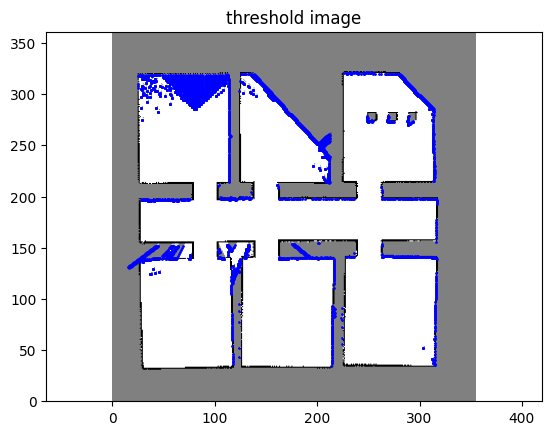

In [5]:
# You can use map or initial
_, im_thresh = open_image("map.pgm")

# Split into two pieces - find all of the points that are adjacent to an unknown area and a visible area. The
#. next question will pick the "best" one
all_unseen = find_all_possible_goals(im_thresh)
assert test_unseen(im_thresh, all_unseen)

# Note: This can be a little slow (it's drawing a lot of little points)
zoom = 1.0
plot_with_explore_points(im_thresh, zoom=1.0, robot_loc=None, explore_points=all_unseen, best_pt=None)

In [6]:
grader.check("unknown_area")

unknown_area results: All test cases passed!

## Find best
No right naswer here, but going to test for a pixel that has at least 3 free neighbors

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


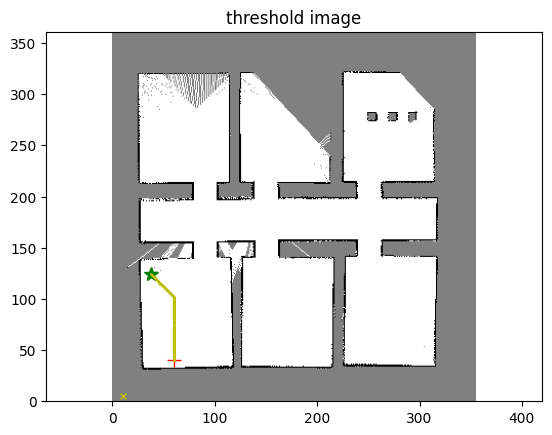

In [7]:
# Where the robot is might influence your choice. Shows path to selected point.
robot_start_loc = (60, 40)
best_unseen = find_best_point(im_thresh, all_unseen, robot_loc=robot_start_loc)
assert test_best(im_thresh, best_unseen)

path = dijkstra(im_thresh, robot_start_loc, best_unseen)
plot_with_path(im_thresh, zoom=1.0, robot_loc=robot_start_loc, goal_loc=best_unseen, path=path)


In [8]:
grader.check("find_best")

find_best results: All test cases passed!

# Run waypoint generation on a pretend SLAM map
Note: This code assumes you have the previous problem completed

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Waypoints has 17 points of 85


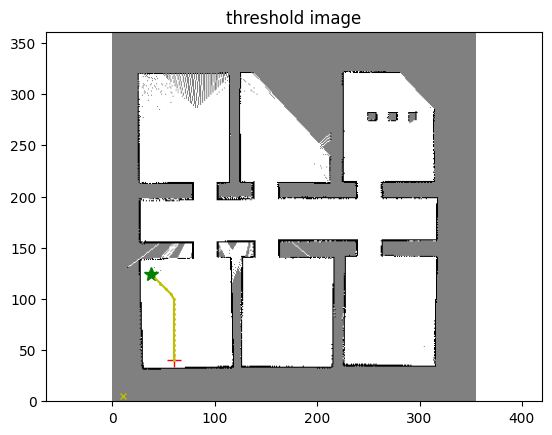

In [9]:
path = dijkstra(im_thresh, robot_start_loc, best_unseen)
waypoints = find_waypoints(im_thresh, path)
plot_with_path(im_thresh, zoom=1.0, robot_loc=robot_start_loc, goal_loc=best_unseen, path=waypoints)
print(f"Waypoints has {len(waypoints)} points of {len(path)}")

In [10]:
grader.check("Waypoints")

Waypoints results: All test cases passed!

## Hours and collaborators
Required for every assignment - fill out before you hand-in.

Listing names and websites helps you to document who you worked with and what internet help you received in the case of any plagiarism issues. You should list names of anyone (in class or not) who has substantially helped you with an assignment - or anyone you have *helped*. You do not need to list TAs.

Listing hours helps us track if the assignments are too long.

In [11]:

# List of names (creates a set)
worked_with_names = {"Aditya Chary"}
# List of URLS W26 (creates a set)
websites = {"None"}
# Approximate number of hours, including lab/in-class time
hours = 5

In [12]:
grader.check("hours_collaborators")

hours_collaborators results: All test cases passed!

### To submit

- Do a restart then run all to make sure everything runs ok
- Save the file
- Submit this .ipynb file and **path_planning.py** and **exploring.py** through gradescope, Lab 4: Explore
- You do NOT need to submit the data files - we will supply those
- Take out/suppress all print statements

If the Gradescope autograder fails, please check here first for common reasons for it to fail
    https://docs.google.com/presentation/d/1tYa5oycUiG4YhXUq5vHvPOpWJ4k_xUPp2rUNIL7Q9RI/edit?usp=sharing

Most likely failure for this assignment is not naming the data directory and files correctly; capitalization matters for the Gradescope grader. 

Second most likely failure is because your code ran very, very slowly and the autograder timed out.

Third reason for failure is you forgot to include **path_planning.py** and **exploring.py** and/or you put the file(s) in a folder